# Precipitation Nowcasting — Experiment Journey

Galápagos weather stations — 3h/6h/12h rainfall forecast horizons.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- All experiment data from PROGRESS.md ---
experiments = [
    ("RF baseline\n(200 trees)", 0.8695, "kept", "flat", 0.879, 0.869, 0.860),
    ("XGBoost\n(500 trees)", 0.8575, "reverted", "flat", 0.875, 0.855, 0.843),
    ("XGBoost\n(300 trees)", 0.8499, "reverted", "flat", 0.861, 0.847, 0.841),
    ("LightGBM\n(500 trees)", 0.8624, "reverted", "flat", 0.874, 0.863, 0.850),
    ("RF + threshold\ntuning", 0.8556, "reverted", "flat", 0.868, 0.857, 0.842),
    ("Prob avg\nRF+LGB+XGB", 0.8689, "reverted", "flat", None, None, None),
    ("Per-horizon\nbest model", 0.8671, "reverted", "flat", 0.877, 0.873, 0.852),
    ("Cascade RF\n(200 trees)", 0.8729, "kept", "cascade", 0.885, 0.872, 0.861),
    ("Cascade +\nphysics feats", 0.8725, "reverted", "cascade", 0.883, 0.872, 0.862),
    ("Cascade +\nOOB threshold", 0.8697, "reverted", "cascade", 0.886, 0.871, 0.853),
    ("Cascade +\nadaptive thresh", 0.8689, "reverted", "cascade", 0.885, 0.869, 0.853),
    ("Cascade RF\n(300 trees)", 0.8731, "kept", "cascade", 0.885, 0.873, 0.862),
    ("Cascade RF\n(400 trees)", 0.8733, "kept", "cascade", 0.886, 0.872, 0.862),
    ("Cascade +\nLGB stage2", 0.8729, "reverted", "cascade", 0.885, 0.871, 0.862),
    ("Cascade\nadapt. depth", 0.8697, "reverted", "cascade", 0.887, 0.872, 0.850),
    ("ExtraTrees\n(500 trees)", 0.8571, "reverted", "cascade", 0.867, 0.855, 0.849),
    ("Cascade+Flat\nblend (BEST)", 0.8738, "kept", "blend", 0.887, 0.874, 0.860),
]

labels = [e[0] for e in experiments]
scores = [e[1] for e in experiments]
statuses = [e[2] for e in experiments]
categories = [e[3] for e in experiments]
f1_3h = [e[4] for e in experiments]
f1_6h = [e[5] for e in experiments]
f1_12h = [e[6] for e in experiments]

## 1. Experiment Journey — Composite Score

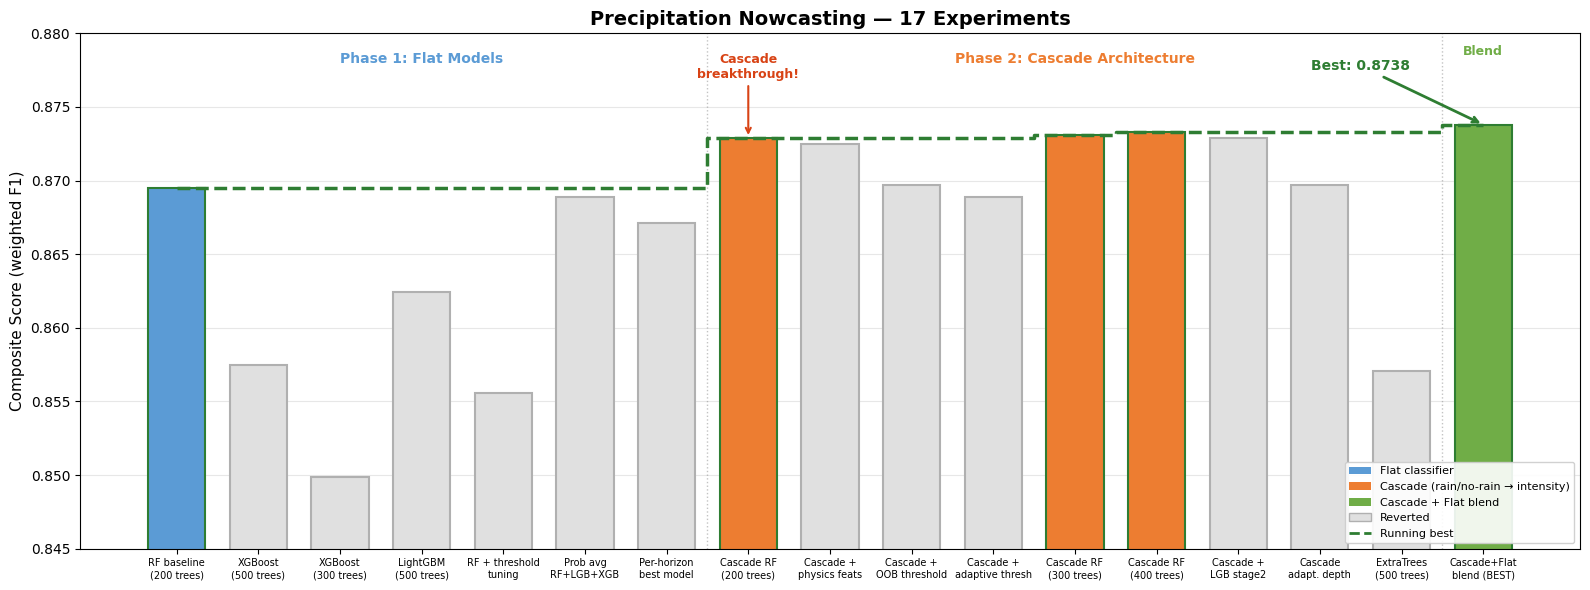

In [2]:
cat_colors = {"flat": "#5B9BD5", "cascade": "#ED7D31", "blend": "#70AD47"}
face_colors = [cat_colors[c] if s == "kept" else "#E0E0E0" for c, s in zip(categories, statuses)]
edge_colors = ["#2E7D32" if s == "kept" else "#B0B0B0" for s in statuses]

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(experiments))
bars = ax.bar(x, scores, color=face_colors, edgecolor=edge_colors, linewidth=1.5, width=0.7)

# Running best line
running_best, best = [], 0
for s, st in zip(scores, statuses):
    if st == "kept" and s > best: best = s
    running_best.append(best)
ax.step(x, running_best, where='mid', color='#2E7D32', lw=2.5, ls='--', label='Running best', zorder=5)

# Annotations
ax.annotate('Cascade\nbreakthrough!', xy=(7, 0.8729), xytext=(7, 0.877),
            fontsize=9, fontweight='bold', color='#D84315', ha='center',
            arrowprops=dict(arrowstyle='->', color='#D84315', lw=1.5))
ax.annotate('Best: 0.8738', xy=(16, 0.8738), xytext=(14.5, 0.8775),
            fontsize=10, fontweight='bold', color='#2E7D32', ha='center',
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))

# Phase separators
ax.axvline(6.5, color='#888', ls=':', lw=1, alpha=0.5)
ax.axvline(15.5, color='#888', ls=':', lw=1, alpha=0.5)
ax.text(3, 0.878, 'Phase 1: Flat Models', ha='center', fontsize=10, color='#5B9BD5', fontweight='bold')
ax.text(11, 0.878, 'Phase 2: Cascade Architecture', ha='center', fontsize=10, color='#ED7D31', fontweight='bold')
ax.text(16, 0.8785, 'Blend', ha='center', fontsize=9, color='#70AD47', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('Composite Score (weighted F1)', fontsize=11)
ax.set_title('Precipitation Nowcasting — 17 Experiments', fontsize=14, fontweight='bold')
ax.set_ylim(0.845, 0.880)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

legend_elements = [
    mpatches.Patch(facecolor='#5B9BD5', label='Flat classifier'),
    mpatches.Patch(facecolor='#ED7D31', label='Cascade (rain/no-rain → intensity)'),
    mpatches.Patch(facecolor='#70AD47', label='Cascade + Flat blend'),
    mpatches.Patch(facecolor='#E0E0E0', edgecolor='#B0B0B0', label='Reverted'),
    plt.Line2D([0], [0], color='#2E7D32', lw=2, ls='--', label='Running best'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

## 2. Per-Horizon F1 Scores — Why 12h Is the Bottleneck

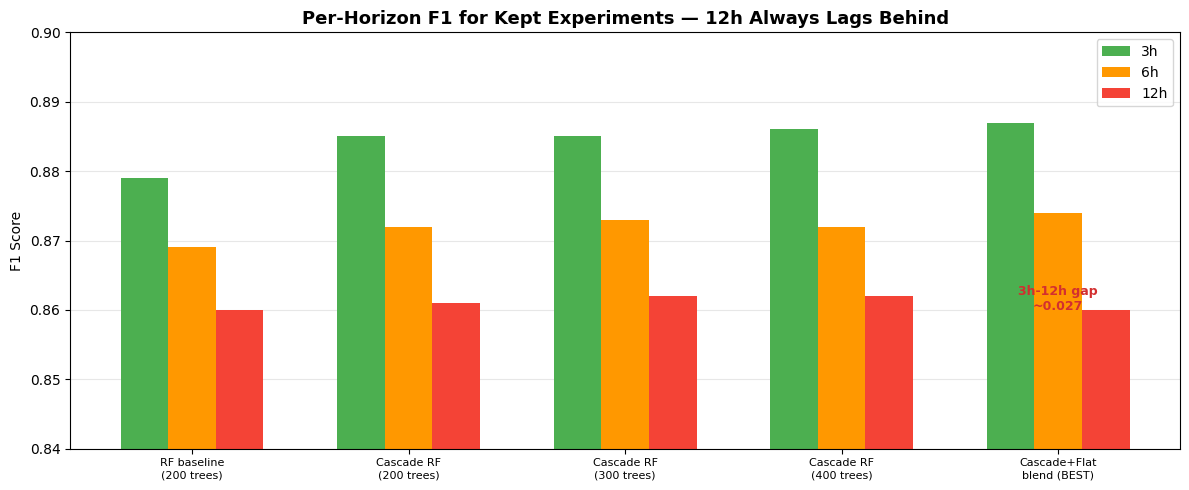

In [3]:
# Only experiments with per-horizon data
kept_exp = [(l, s, f3, f6, f12) for l, s, st, _, f3, f6, f12 in experiments
            if st == "kept" and f3 is not None]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(kept_exp))
w = 0.22
ax.bar(x - w, [e[2] for e in kept_exp], w, label='3h', color='#4CAF50')
ax.bar(x, [e[3] for e in kept_exp], w, label='6h', color='#FF9800')
ax.bar(x + w, [e[4] for e in kept_exp], w, label='12h', color='#F44336')

ax.set_xticks(x)
ax.set_xticklabels([e[0] for e in kept_exp], fontsize=8)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Horizon F1 for Kept Experiments — 12h Always Lags Behind', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.84, 0.90)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Gap annotation
ax.annotate('3h-12h gap\n~0.027', xy=(len(kept_exp)-1, 0.860), fontsize=9,
            color='#D32F2F', fontweight='bold', ha='center')
plt.tight_layout()
plt.show()

## 3. What Worked vs What Didn't

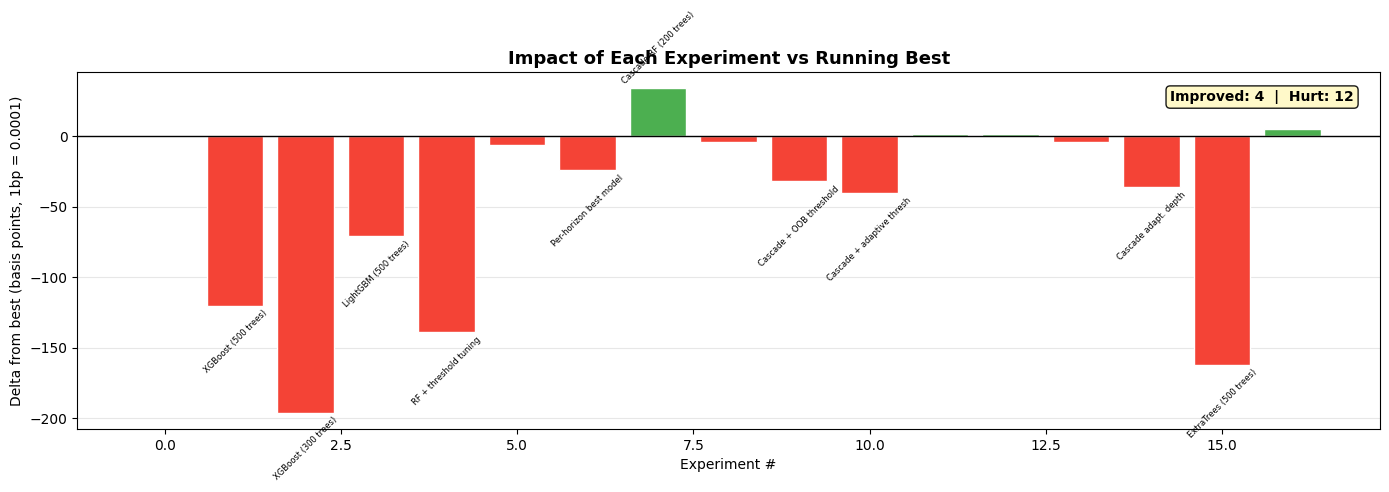

In [4]:
# Scatter: what helped vs what hurt
deltas = []
for i, (l, s, st, cat, *_) in enumerate(experiments):
    if i == 0:
        deltas.append(0)
    else:
        # Delta from the running best at the time
        prev_best = max(sc for sc, stt in zip(scores[:i], statuses[:i]) if stt == "kept") if any(stt == "kept" for stt in statuses[:i]) else scores[0]
        deltas.append(s - prev_best)

fig, ax = plt.subplots(figsize=(14, 5))
colors_delta = ['#4CAF50' if d >= 0 else '#F44336' for d in deltas]
bars = ax.bar(range(len(deltas)), [d * 10000 for d in deltas], color=colors_delta, edgecolor='white')

# Label the approaches
for i, (d, l) in enumerate(zip(deltas, labels)):
    short_l = l.replace('\n', ' ')
    if abs(d) > 0.001:
        ax.text(i, d * 10000 + (2 if d >= 0 else -2), short_l, ha='center', va='bottom' if d >= 0 else 'top',
                fontsize=6, rotation=45)

ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Experiment #')
ax.set_ylabel('Delta from best (basis points, 1bp = 0.0001)')
ax.set_title('Impact of Each Experiment vs Running Best', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Summary stats
n_improved = sum(1 for d in deltas if d > 0)
n_hurt = sum(1 for d in deltas if d < 0)
ax.text(0.98, 0.95, f'Improved: {n_improved}  |  Hurt: {n_hurt}', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.9))
plt.tight_layout()
plt.show()

## 4. Key Findings Summary

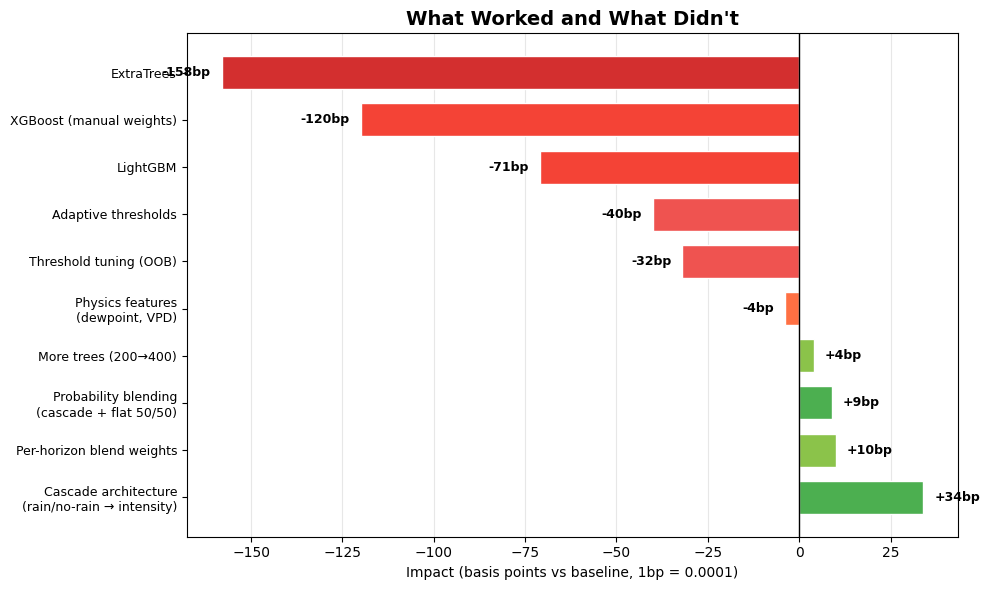

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

findings = [
    ("Cascade architecture\n(rain/no-rain → intensity)", +34, '#4CAF50'),
    ("Probability blending\n(cascade + flat 50/50)", +9, '#4CAF50'),
    ("More trees (200→400)", +4, '#8BC34A'),
    ("Per-horizon blend weights", +10, '#8BC34A'),
    ("XGBoost (manual weights)", -120, '#F44336'),
    ("LightGBM", -71, '#F44336'),
    ("Threshold tuning (OOB)", -32, '#EF5350'),
    ("Adaptive thresholds", -40, '#EF5350'),
    ("Physics features\n(dewpoint, VPD)", -4, '#FF7043'),
    ("ExtraTrees", -158, '#D32F2F'),
]

findings.sort(key=lambda x: x[1], reverse=True)
y = range(len(findings))
colors = [f[2] for f in findings]
vals = [f[1] for f in findings]
names = [f[0] for f in findings]

bars = ax.barh(y, vals, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(y)
ax.set_yticklabels(names, fontsize=9)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Impact (basis points vs baseline, 1bp = 0.0001)')
ax.set_title('What Worked and What Didn\'t', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

for bar, val in zip(bars, vals):
    x_pos = bar.get_width() + (3 if val >= 0 else -3)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:+d}bp',
            ha=ha, va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()